In [43]:
+import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import linear_model

In [2]:
df=pd.read_csv("new_insurance_data (1).csv")
df.head(5)

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [3]:
df.isnull().sum().sum()

np.int64(52)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [5]:
col=list(df.columns)
col

['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'Claim_Amount',
 'past_consultations',
 'num_of_steps',
 'Hospital_expenditure',
 'NUmber_of_past_hospitalizations',
 'Anual_Salary',
 'region',
 'charges']

In [6]:
#for i in col:
  #  if df[i].dtype=='object':
  #      df[i]=df[i].fillna(df[i].mode()[0])
  #  else:
   #     df[i]=df[i].fillna(df[i].mean())




for i in col:
    if df[i].dtype=='object':
        df[i]=df[i].fillna(df[i].mode()[0])
    else:
        df[i] = df[i].fillna(df[i].mean())

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1338 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1338 non-null   float64
 3   children                         1338 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1338 non-null   float64
 6   past_consultations               1338 non-null   float64
 7   num_of_steps                     1338 non-null   float64
 8   Hospital_expenditure             1338 non-null   float64
 9   NUmber_of_past_hospitalizations  1338 non-null   float64
 10  Anual_Salary                     1338 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(0)

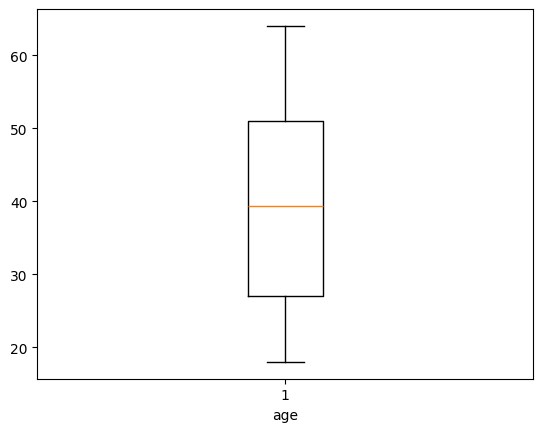

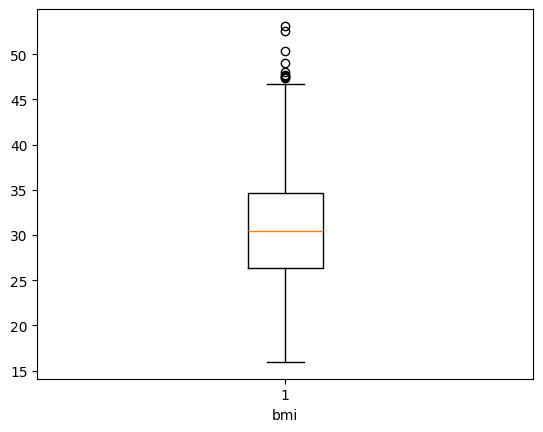

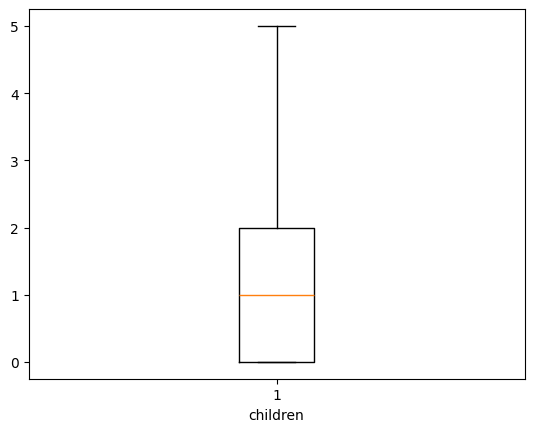

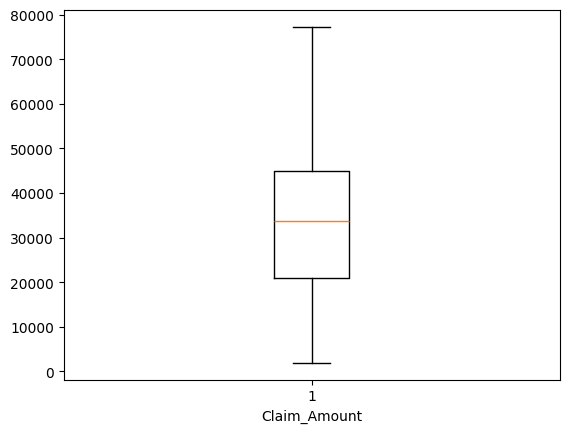

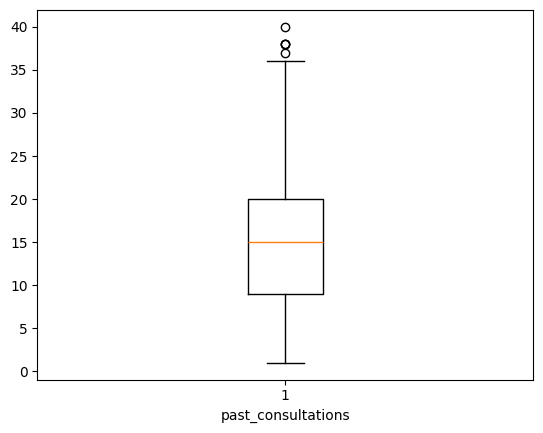

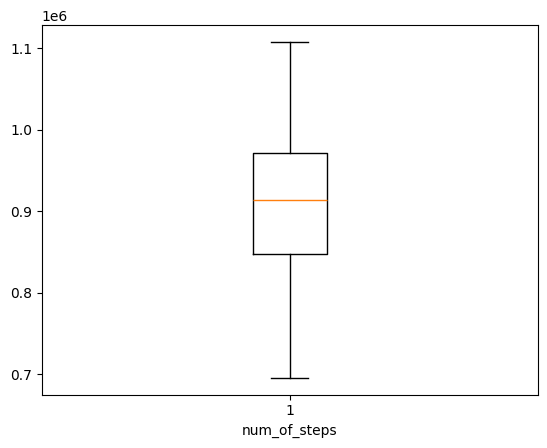

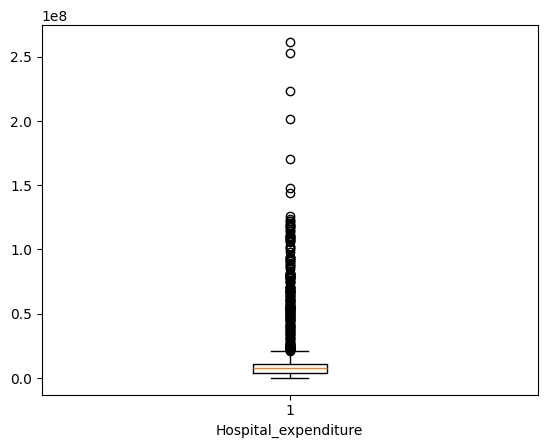

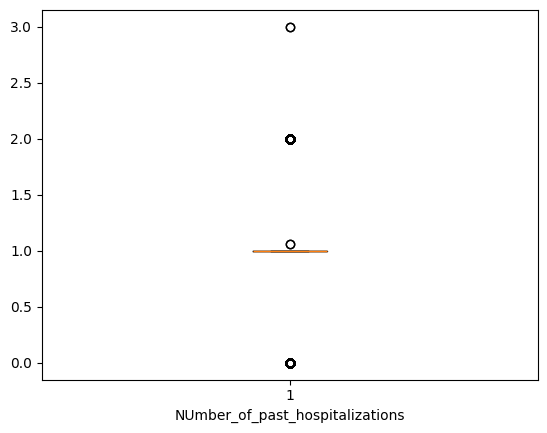

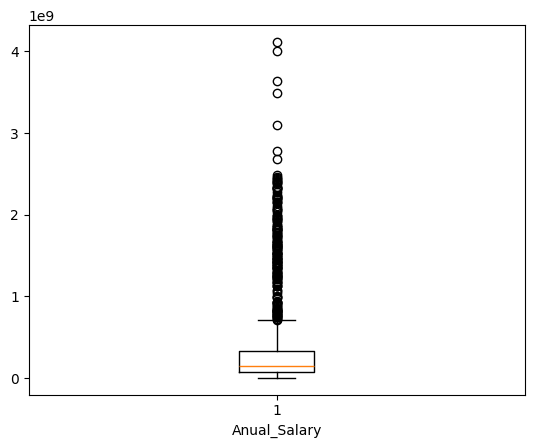

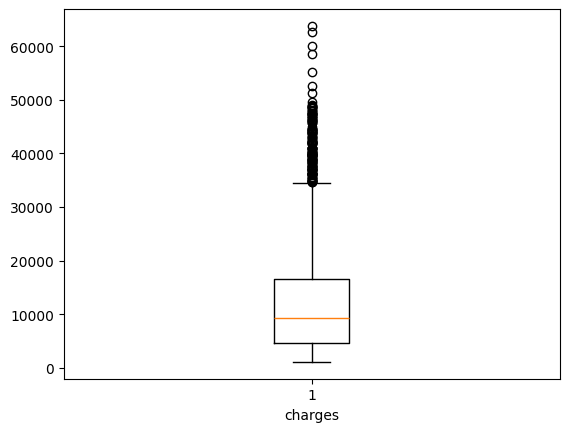

In [10]:
# Outliers

for i in col:
    if (df[i].dtype!='object'):
        plt.boxplot(df[i])
        plt.xlabel(i)
        plt.show()

In [11]:
#Removing outlires
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [12]:
x=['bmi','past_consultations','Hospital_expenditure','NUmber_of_past_hospitalizations','Anual_Salary','charges']

In [13]:
for i in x:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lf=q1-1.5*IQR
    uf=q3+1.5*IQR

    df=df[(df[i]>=lf) & (df[i]<=uf)]

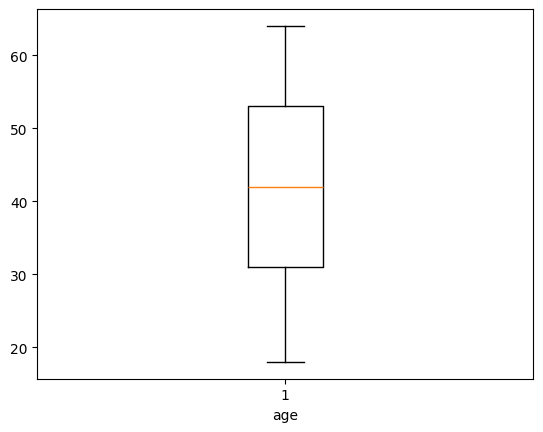

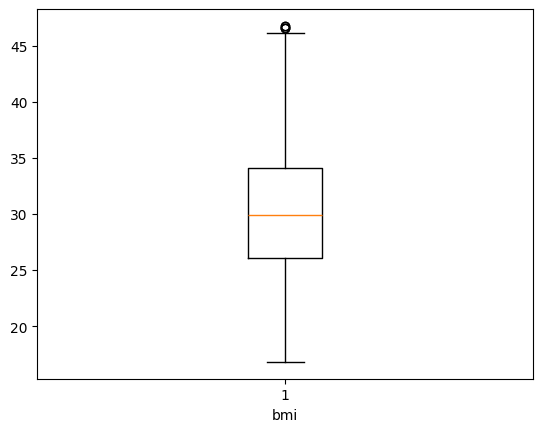

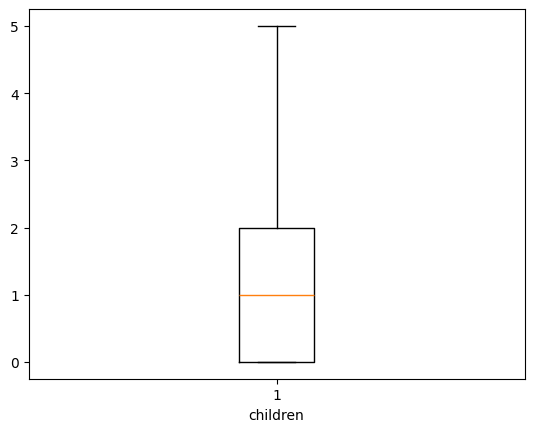

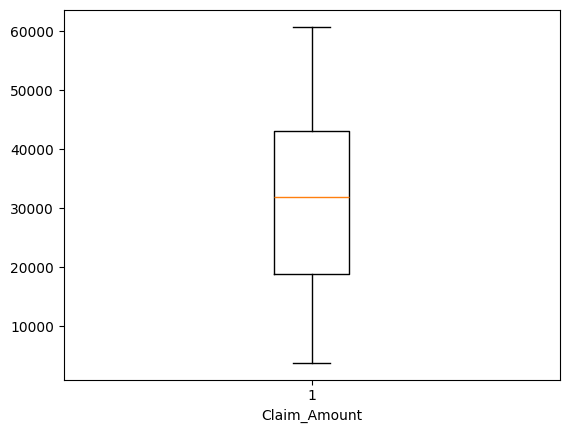

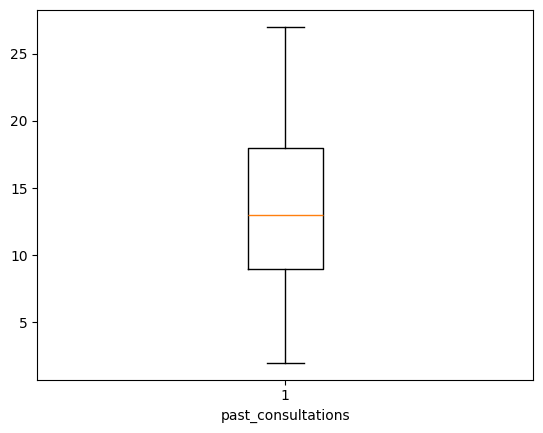

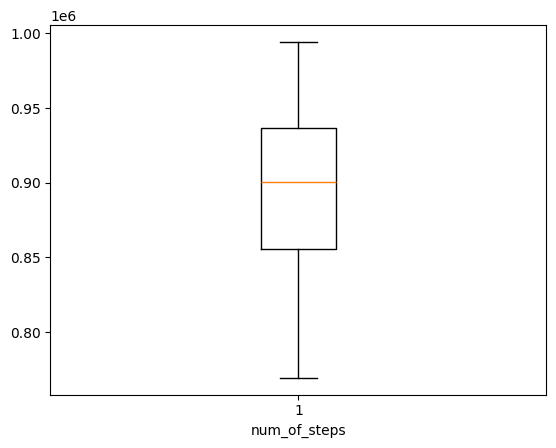

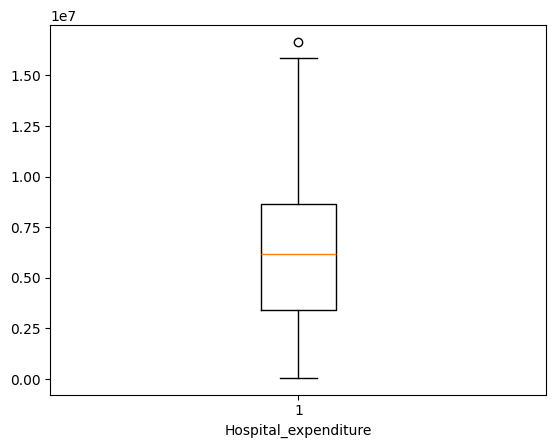

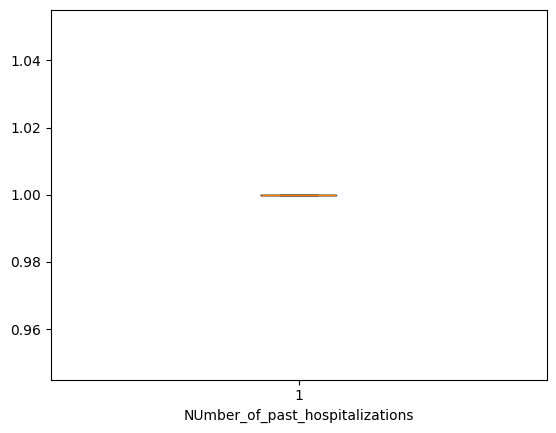

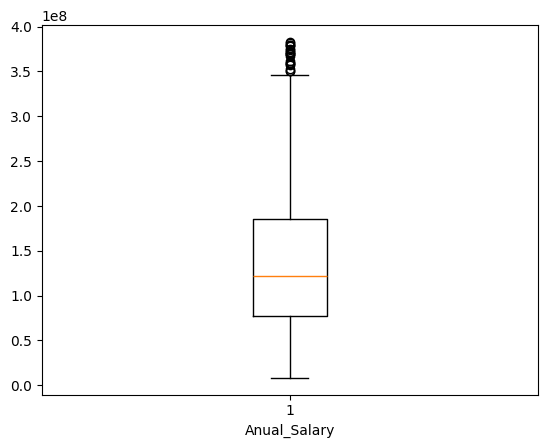

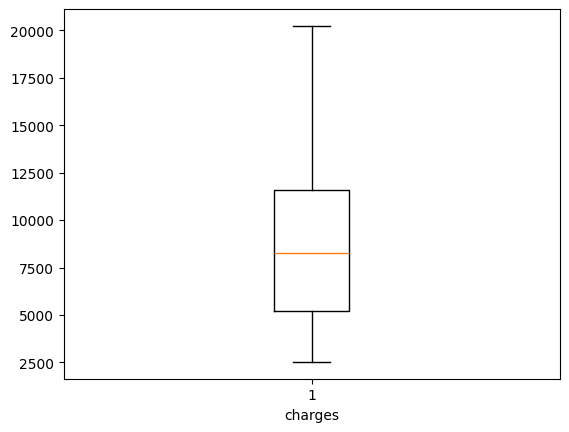

In [14]:
for i in df.columns:
    if(df[i].dtype!='object'):
        plt.boxplot(df[i])
        plt.xlabel(i)
        plt.show()

In [15]:
# Label Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
le=LabelEncoder()

In [18]:
for i in df.columns:
    if df[i].dtype=='object':
        df[i]=le.fit_transform(df[i])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 151 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              881 non-null    float64
 1   sex                              881 non-null    int64  
 2   bmi                              881 non-null    float64
 3   children                         881 non-null    float64
 4   smoker                           881 non-null    int64  
 5   Claim_Amount                     881 non-null    float64
 6   past_consultations               881 non-null    float64
 7   num_of_steps                     881 non-null    float64
 8   Hospital_expenditure             881 non-null    float64
 9   NUmber_of_past_hospitalizations  881 non-null    float64
 10  Anual_Salary                     881 non-null    float64
 11  region                           881 non-null    int64  
 12  charges                 

In [20]:
#model creation

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [27]:
x=df.drop(columns=['charges'])
y=df['charges']

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.5,random_state=42)

In [32]:
my_model=LinearRegression()

In [33]:
my_model.fit(x_train,y_train)

LinearRegression()

In [35]:
y_pred=my_model.predict(x_test)
y_pred

array([ 7622.82297667,  5149.29248399,  9512.88604035, 11125.45568056,
        7073.8064584 ,  3259.11266802, 10211.75749013, 13269.99158114,
        8655.02222227, 12063.20521595, 12544.02137371, 12376.79309787,
        5988.00024858, 14992.24038809, 13420.27264724,  7893.69985534,
        6465.34944957,  7235.56653488,  8097.82684711, 12032.13691212,
        8146.23596317,  1613.61997833,  7801.09297934,  1891.37049138,
        6670.33705597, 12590.05182092,  7333.57948223, 14139.00545116,
       11599.28090295,  7077.07157794,  9741.97759727,  3223.70343878,
        7723.37288922,  5010.0491574 ,  8352.08242601,  5725.51780002,
        2750.21990779, 10196.31108745,  6666.19483974,  2049.33820753,
        5869.73973559,  3528.05174451, 18142.85359441,  8967.47871846,
       11697.76943198,  4857.71106662, 12910.76829567,  7845.95613301,
        2910.2577369 , 12069.88232754,  6319.78500067, 15040.17864973,
        9975.77584278,  4293.9662866 , 15073.07904986,  7581.31218302,
      

In [36]:
y_test

501      6986.6970
405      5615.3690
642      8944.1151
843     11945.1327
544      7512.2670
           ...    
877     12574.0490
440      6186.1270
389      5383.5360
151      2523.1695
1030    18259.2160
Name: charges, Length: 441, dtype: float64

In [37]:
result=pd.DataFrame(columns=['Actual_value-y_pred','Predicted_value-y_pred'])
result['Actual_value-y_test']=y_test
result['Predicted _value-y_pred']=y_pred

In [38]:
result

,Actual_value-y_pred,Predicted_value-y_pred,Actual_value-y_test,Predicted _value-y_pred
501,NaN,NaN,6986.6970,7622.822977
405,NaN,NaN,5615.3690,5149.292484
642,NaN,NaN,8944.1151,9512.886040
843,NaN,NaN,11945.1327,11125.455681
544,NaN,NaN,7512.2670,7073.806458
...,...,...,...,...
877,NaN,NaN,12574.0490,12851.717498
440,NaN,NaN,6186.1270,7332.955096
389,NaN,NaN,5383.5360,4684.853476
151,NaN,NaN,2523.1695,1258.228174


In [39]:
from sklearn.metrics import *

In [40]:
result= r2_score(y_test,y_pred)

In [41]:
result

0.9612554254128157

<Axes: ylabel='charges'>

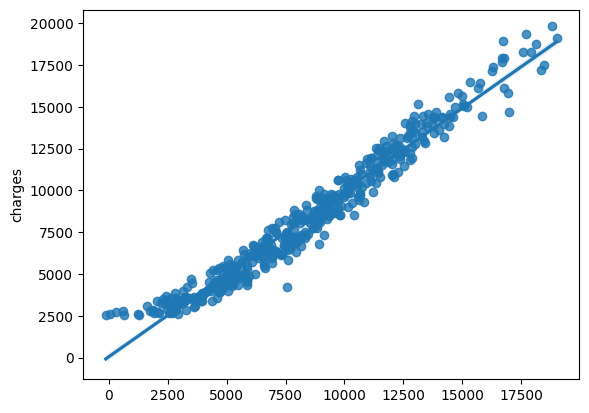

In [47]:
sns.regplot(x=y_pred,y=y_test)